###Projection Methods: PCA, t-SNE

In [ ]:
#PCA
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [ ]:

# Load the Iris dataset
#features 4, #samples 150
iris = load_iris()
X = iris.data
y = iris.target

In [ ]:
# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_pca

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

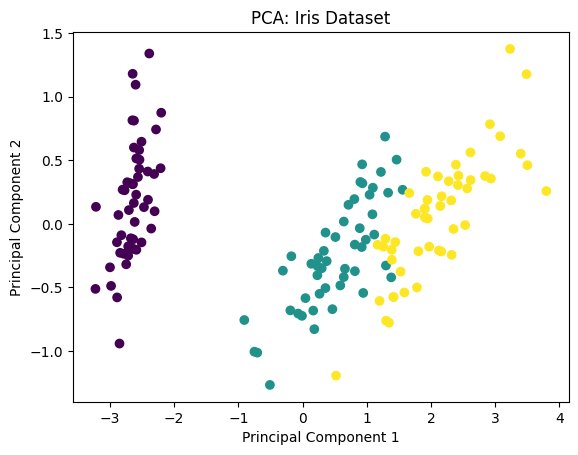

In [ ]:
# Plot the reduced data
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Iris Dataset')
plt.show()


Apply TSNE

In [ ]:
#TSNE
from sklearn.manifold import TSNE
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [ ]:

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target


In [ ]:
# Apply t-SNE to reduce to 2 dimensions
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X)
X_tsne

array([[-2.42846699e+01, -1.96068853e-01],
       [-2.17319050e+01,  6.53882325e-01],
       [-2.17767735e+01, -4.33847994e-01],
       [-2.14130859e+01, -1.41203120e-01],
       [-2.42849083e+01, -6.06253624e-01],
       [-2.62441120e+01, -5.33888757e-01],
       [-2.20059872e+01, -7.92660773e-01],
       [-2.36063728e+01,  8.98885578e-02],
       [-2.08891449e+01, -8.28106523e-01],
       [-2.22197151e+01,  4.80458289e-01],
       [-2.58226967e+01,  8.83378163e-02],
       [-2.29560204e+01,  3.29243898e-01],
       [-2.14609852e+01,  4.00310963e-01],
       [-2.04171238e+01, -7.15105116e-01],
       [-2.71277199e+01,  4.87351343e-02],
       [-2.72579269e+01, -4.86495912e-01],
       [-2.64031487e+01, -2.06707284e-01],
       [-2.43507843e+01, -6.94209263e-02],
       [-2.66233368e+01,  3.07076067e-01],
       [-2.53120079e+01, -6.81390285e-01],
       [-2.52586861e+01,  9.00316954e-01],
       [-2.50500813e+01, -4.59083408e-01],
       [-2.02292347e+01,  2.96012908e-01],
       [-2.

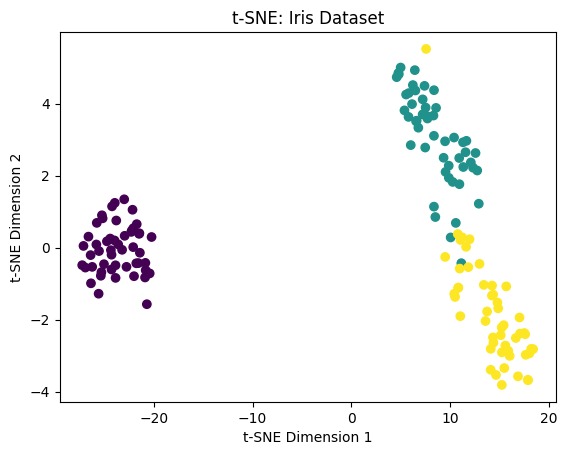

In [ ]:
# Plot the reduced data
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE: Iris Dataset')
plt.show()

###Filter Methods: ANOVA, Chi2, Mutual Info, Variance Threshold

In [ ]:
#SelectKBest method
#scoring function ANOVA F-Statistic
from sklearn.datasets import load_iris

# Load the Iris dataset as an example
iris = load_iris()
X = iris.data
y = iris.target

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
# Create SelectKBest object with ANOVA F-statistic scoring function
k_best = SelectKBest(score_func=f_classif, k=2)  # Select the top 2 features
X_k_best = k_best.fit_transform(X, y)
# Print the selected features
selected_features = k_best.get_support(indices=True)
print("Selected Features:", selected_features)
#get feature scores
feature_scores = k_best.scores_
print("Feature Scores:", feature_scores)

Selected Features: [2 3]
Feature Scores: [ 119.26450218   49.16004009 1180.16118225  960.0071468 ]


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

#chi2
# SelectKBest with chi-squared
k_best_chi2 = SelectKBest(score_func=chi2, k=2)
X_chi2 = k_best_chi2.fit_transform(X, y)
print("Selected Features (Chi-squared):")
print("Number of Selected Features:", X_chi2.shape[1])
print("List of Selected Features:", k_best_chi2.get_support(indices=True))
print("\n")
#get feature scores
feature_scores = k_best_chi2.scores_
print("Feature Scores:", feature_scores)


Selected Features (Chi-squared):
Number of Selected Features: 2
List of Selected Features: [2 3]


Feature Scores: [ 10.81782088   3.7107283  116.31261309  67.0483602 ]


In [ ]:
#mutual info
from sklearn.feature_selection import SelectKBest, mutual_info_classif
# Apply SelectKBest with mutual information
# feature selection based on mutual information for classification tasks
#For classification tasks, mutual_info_classif calculates the mutual information between each feature and the target variable.
k_best_mi = SelectKBest(score_func=mutual_info_classif, k=2)  # Adjust 'k' based on your preference
X_mi = k_best_mi.fit_transform(X, y)
print("List of Selected Features:", k_best_mi.get_support(indices=True))
print("\n")
#get feature scores
feature_scores = k_best_mi.scores_
print("Feature Scores:", feature_scores)

List of Selected Features: [2 3]


Feature Scores: [0.49115684 0.23130301 0.98364824 0.98039894]


In [ ]:
from sklearn.feature_selection import VarianceThreshold
# Apply VarianceThreshold
 # Adjust the threshold based on your preference
variance_selector = VarianceThreshold(threshold=0.3)
X_variance = variance_selector.fit_transform(X)
X_variance
print("Selected Features (Variance Threshold):")
print("Number of Selected Features:", X_variance.shape[1])
print("List of Selected Features:", variance_selector.get_support(indices=True))
print("\n")
#get feature variances
feature_scores = variance_selector.variances_
print("Variances:", feature_scores)

Selected Features (Variance Threshold):
Number of Selected Features: 3
List of Selected Features: [0 2 3]


Variances: [0.68112222 0.18871289 3.09550267 0.57713289]
